In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Fix working directory to project root
os.chdir(r'D:\predictive-maintenance-sme')

print("Working directory:", os.getcwd())
print("assets exists    :", os.path.exists('assets'))
print("data/raw exists  :", os.path.exists('data/raw'))

# Load dataset
df = pd.read_csv('data/raw/ai4i2020.csv')
df.columns = df.columns.str.strip()

print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())

Working directory: D:\predictive-maintenance-sme
assets exists    : True
data/raw exists  : True

Shape: (10000, 14)
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [13]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing)

print("\n=== Failure Statistics ===")
total    = len(df)
failures = int(df['Machine failure'].sum())
normal   = total - failures

print(f"Total rows   : {total}")
print(f"Failures     : {failures}")
print(f"Normal       : {normal}")
print(f"Failure rate : {failures/total:.2%}")

=== Data Types ===
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

=== Missing Values ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

=== Failure Statistics ===
Total 

In [14]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print("=== Failure Mode Counts ===")
for mode in failure_modes:
    count = int(df[mode].sum())
    pct   = count / total * 100
    print(f"  {mode}: {count} ({pct:.2f}%)")

print("\n=== Machine Type Distribution ===")
print(df['Type'].value_counts())

print("\n=== Failure Rate by Machine Type ===")
type_stats = df.groupby('Type')['Machine failure'].agg(
    failures='sum',
    total='count'
)
type_stats['failure_rate_pct'] = (
    type_stats['failures'] / type_stats['total'] * 100
).round(2)
print(type_stats)

=== Failure Mode Counts ===
  TWF: 46 (0.46%)
  HDF: 115 (1.15%)
  PWF: 95 (0.95%)
  OSF: 98 (0.98%)
  RNF: 19 (0.19%)

=== Machine Type Distribution ===
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

=== Failure Rate by Machine Type ===
      failures  total  failure_rate_pct
Type                                   
H           21   1003              2.09
L          235   6000              3.92
M           83   2997              2.77


In [15]:
sensors = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

print("=== Sensor Statistics — Normal vs Failure ===\n")
for col in sensors:
    normal_mean  = df[df['Machine failure']==0][col].mean()
    failure_mean = df[df['Machine failure']==1][col].mean()
    diff_pct     = (failure_mean - normal_mean) / normal_mean * 100
    print(f"{col}")
    print(f"  Normal mean  : {normal_mean:.2f}")
    print(f"  Failure mean : {failure_mean:.2f}")
    print(f"  Difference   : {diff_pct:+.1f}%")
    print()

=== Sensor Statistics — Normal vs Failure ===

Air temperature [K]
  Normal mean  : 299.97
  Failure mean : 300.89
  Difference   : +0.3%

Process temperature [K]
  Normal mean  : 310.00
  Failure mean : 310.29
  Difference   : +0.1%

Rotational speed [rpm]
  Normal mean  : 1540.26
  Failure mean : 1496.49
  Difference   : -2.8%

Torque [Nm]
  Normal mean  : 39.63
  Failure mean : 50.17
  Difference   : +26.6%

Tool wear [min]
  Normal mean  : 106.69
  Failure mean : 143.78
  Difference   : +34.8%



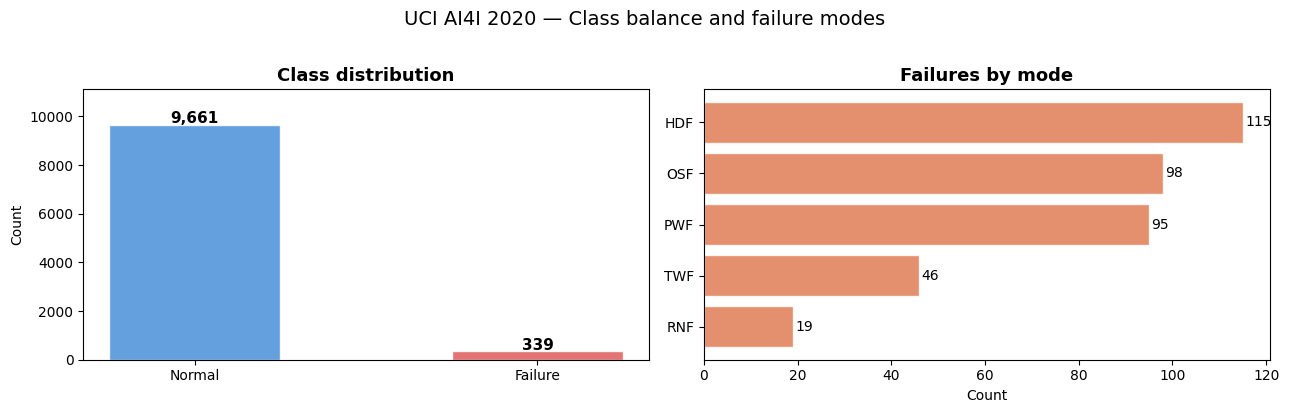

Saved: assets/class_distribution.png


In [16]:
os.makedirs('../assets', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))


counts = df['Machine failure'].value_counts().sort_index()
bars = axes[0].bar(
    ['Normal', 'Failure'],
    counts.values,
    color=['#4a90d9', '#e05c5c'],
    alpha=0.85,
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Class distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 80,
        f'{val:,}',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Right — failure modes
mode_counts = df[failure_modes].sum().sort_values()
axes[1].barh(
    mode_counts.index,
    mode_counts.values,
    color='#e07b54',
    alpha=0.85,
    edgecolor='white'
)
axes[1].set_title('Failures by mode', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
for i, val in enumerate(mode_counts.values):
    axes[1].text(val + 0.5, i, str(int(val)), va='center')

plt.suptitle(
    'UCI AI4I 2020 — Class balance and failure modes',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('D:/predictive-maintenance-sme/assets/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/class_distribution.png")

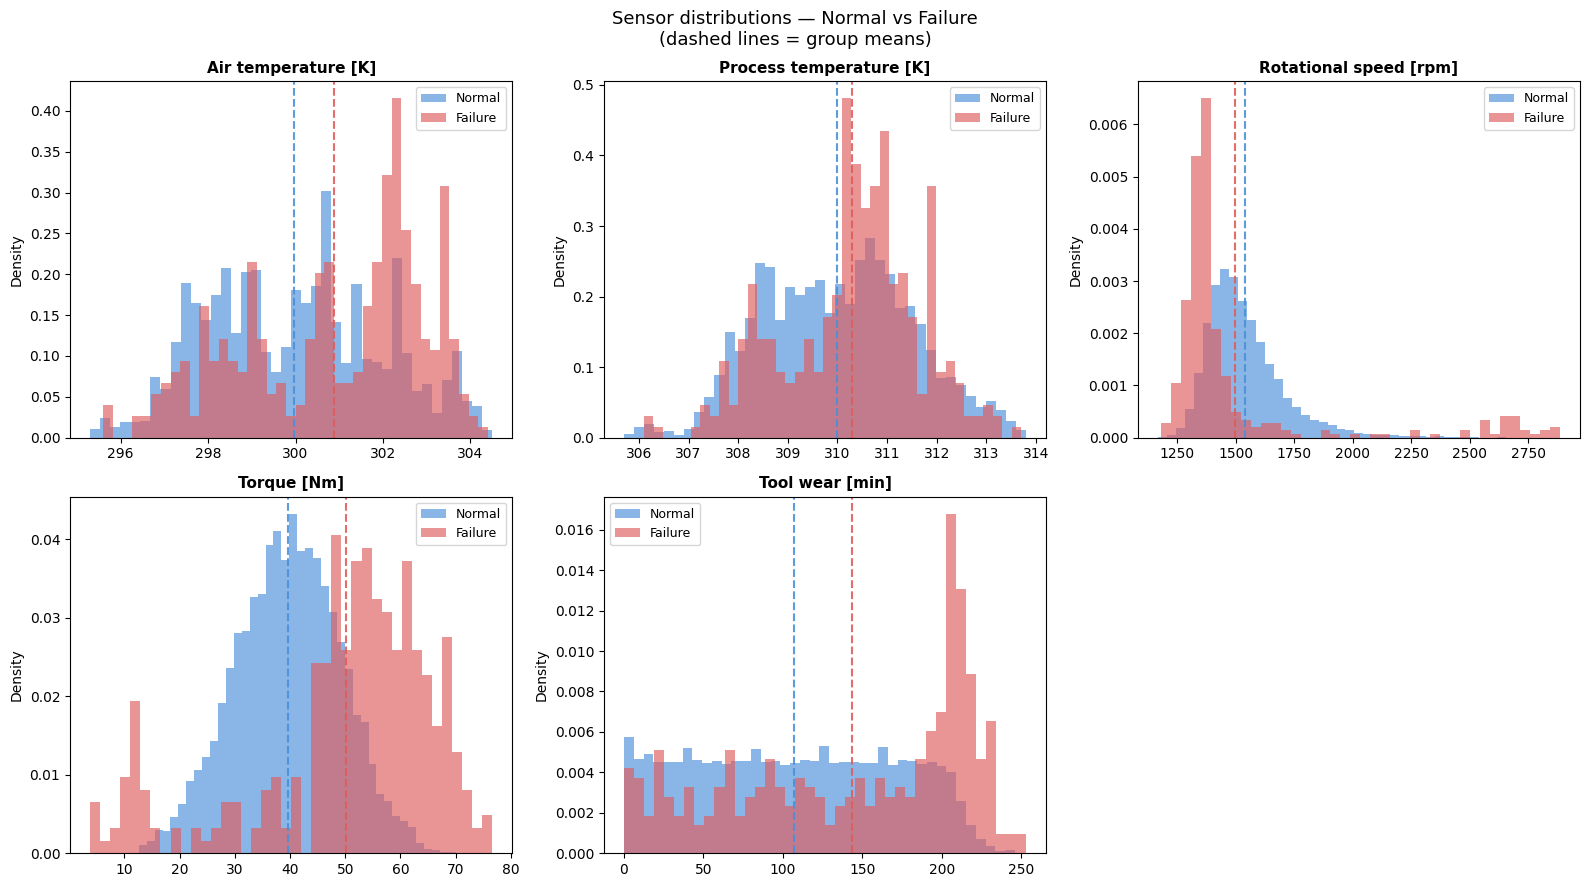

Saved: assets/sensor_distributions.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = {'Normal': '#4a90d9', 'Failure': '#e05c5c'}

for i, col in enumerate(sensors):
    normal_data  = df[df['Machine failure'] == 0][col]
    failure_data = df[df['Machine failure'] == 1][col]

    axes[i].hist(
        normal_data, bins=40, alpha=0.65,
        color=colors['Normal'], label='Normal', density=True
    )
    axes[i].hist(
        failure_data, bins=40, alpha=0.65,
        color=colors['Failure'], label='Failure', density=True
    )

    # Add mean lines
    axes[i].axvline(
        normal_data.mean(), color='#4a90d9',
        linestyle='--', linewidth=1.5, alpha=0.9
    )
    axes[i].axvline(
        failure_data.mean(), color='#e05c5c',
        linestyle='--', linewidth=1.5, alpha=0.9
    )

    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

axes[5].axis('off')

plt.suptitle(
    'Sensor distributions — Normal vs Failure\n(dashed lines = group means)',
    fontsize=13
)
plt.tight_layout()
plt.savefig(
    'D:/predictive-maintenance-sme/assets/sensor_distributions.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Saved: assets/sensor_distributions.png")

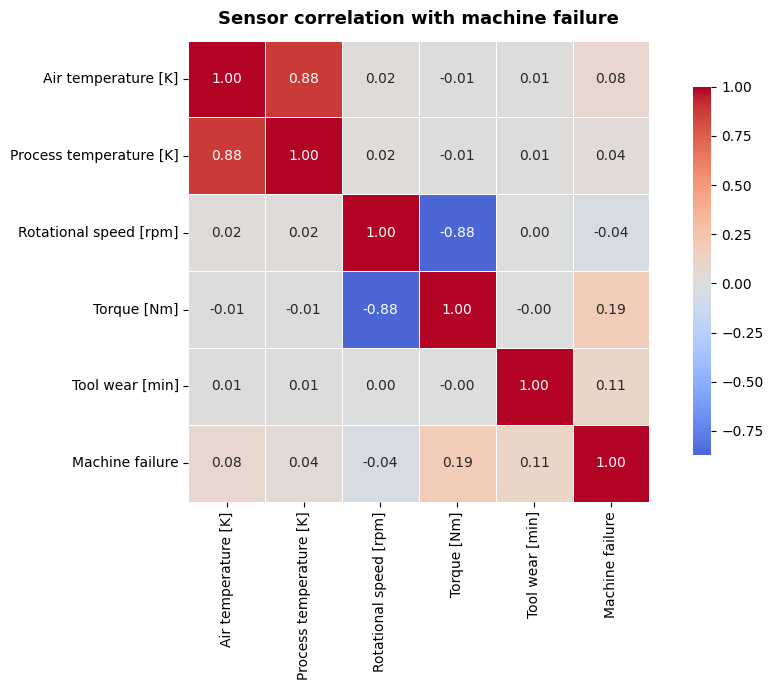

Saved: assets/correlation_heatmap.png


In [18]:
plt.figure(figsize=(10, 7))

corr_cols = sensors + ['Machine failure']
corr      = df[corr_cols].corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 10}
)

plt.title(
    'Sensor correlation with machine failure',
    fontsize=13, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig(
    'D:/predictive-maintenance-sme/assets/correlation_heatmap.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Saved: assets/correlation_heatmap.png")

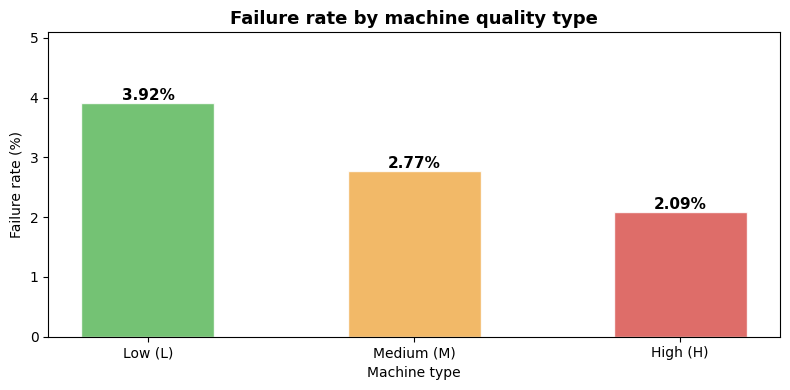

Saved: assets/failure_by_type.png


In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

type_failure_rate = df.groupby('Type')['Machine failure'].mean() * 100
type_failure_rate = type_failure_rate.reindex(['L', 'M', 'H'])

bars = ax.bar(
    ['Low (L)', 'Medium (M)', 'High (H)'],
    type_failure_rate.values,
    color=['#5cb85c', '#f0ad4e', '#d9534f'],
    alpha=0.85,
    edgecolor='white',
    width=0.5
)

ax.set_title(
    'Failure rate by machine quality type',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Failure rate (%)')
ax.set_xlabel('Machine type')

for bar, val in zip(bars, type_failure_rate.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.2f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.set_ylim(0, max(type_failure_rate.values) * 1.3)
plt.tight_layout()
plt.savefig(
    'D:/predictive-maintenance-sme/assets/failure_by_type.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Saved: assets/failure_by_type.png")

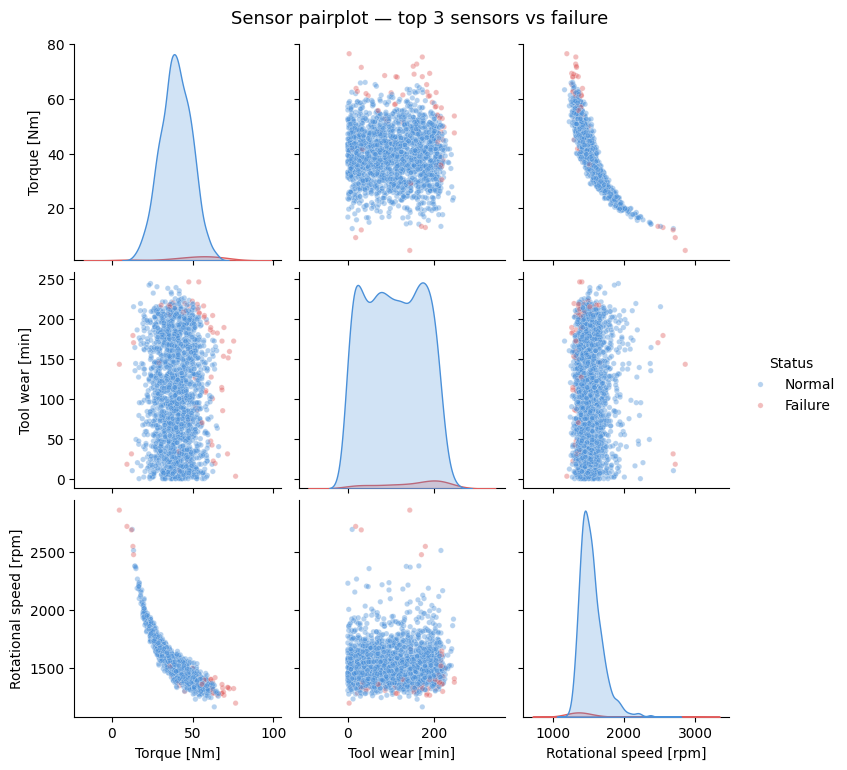

Saved: assets/pairplot.png


In [20]:
import warnings
warnings.filterwarnings('ignore')

sample = df.sample(n=2000, random_state=42)
sample['Status'] = sample['Machine failure'].map(
    {0: 'Normal', 1: 'Failure'}
)

pair_cols = ['Torque [Nm]', 'Tool wear [min]',
             'Rotational speed [rpm]', 'Status']

g = sns.pairplot(
    sample[pair_cols],
    hue='Status',
    palette={'Normal': '#4a90d9', 'Failure': '#e05c5c'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle(
    'Sensor pairplot — top 3 sensors vs failure',
    y=1.02, fontsize=13
)
plt.savefig(
    'D:/predictive-maintenance-sme/assets/pairplot.png',
    dpi=100, bbox_inches='tight'
)
plt.show()
print("Saved: assets/pairplot.png")

In [21]:
os.makedirs('../data/processed', exist_ok=True)

# Top correlations with failure
corr_with_failure = (
    df[sensors + ['Machine failure']]
    .corr()['Machine failure']
    .drop('Machine failure')
    .abs()
    .sort_values(ascending=False)
)

summary = {
    'dataset': 'UCI AI4I 2020 Predictive Maintenance',
    'total_rows': int(total),
    'failure_count': int(failures),
    'normal_count': int(normal),
    'failure_rate_pct': round(failures / total * 100, 2),
    'sensors': sensors,
    'failure_modes': failure_modes,
    'failure_mode_counts': {
        mode: int(df[mode].sum()) for mode in failure_modes
    },
    'machine_type_counts': df['Type'].value_counts().to_dict(),
    'top_correlated_sensors': corr_with_failure.head(3).index.tolist(),
    'key_observations': [
        'Dataset is highly imbalanced — 3.4% failure rate',
        'Tool wear and torque show strongest correlation with failure',
        'High quality machines (H) have higher failure rate than L and M',
        'No missing values — dataset is clean',
        'Use PR-AUC not accuracy — accuracy is misleading on this data',
        'Five distinct failure modes: TWF, HDF, PWF, OSF, RNF'
    ],
    'meti_alignment': [
        'Simulates real Japanese SME sensor data constraints',
        'No expensive IoT hardware assumed',
        'Designed for legacy machine compatibility',
        'Aligned with METI DX agenda for manufacturing SMEs'
    ]
}

with open('D:/predictive-maintenance-sme/data/processed/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("=== EDA Summary ===")
print(f"Dataset        : {summary['dataset']}")
print(f"Total rows     : {summary['total_rows']:,}")
print(f"Failures       : {summary['failure_count']}")
print(f"Failure rate   : {summary['failure_rate_pct']}%")
print(f"\nTop correlated sensors with failure:")
for sensor in summary['top_correlated_sensors']:
    print(f"  {sensor}: {corr_with_failure[sensor]:.4f}")
print(f"\nKey observations:")
for obs in summary['key_observations']:
    print(f"  - {obs}")
print("\nSaved: data/processed/eda_summary.json")

=== EDA Summary ===
Dataset        : UCI AI4I 2020 Predictive Maintenance
Total rows     : 10,000
Failures       : 339
Failure rate   : 3.39%

Top correlated sensors with failure:
  Torque [Nm]: 0.1913
  Tool wear [min]: 0.1054
  Air temperature [K]: 0.0826

Key observations:
  - Dataset is highly imbalanced — 3.4% failure rate
  - Tool wear and torque show strongest correlation with failure
  - High quality machines (H) have higher failure rate than L and M
  - No missing values — dataset is clean
  - Use PR-AUC not accuracy — accuracy is misleading on this data
  - Five distinct failure modes: TWF, HDF, PWF, OSF, RNF

Saved: data/processed/eda_summary.json


In [22]:
import os

# Verify correct location
print("Notebook location:", os.getcwd())

# Fix working directory to project root
project_root = r'D:\predictive-maintenance-sme'
os.chdir(project_root)
print("Working directory:", os.getcwd())

# Create required folders
os.makedirs('assets', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
print("assets/ folder ready:", os.path.exists('assets'))

Notebook location: D:\predictive-maintenance-sme
Working directory: D:\predictive-maintenance-sme
assets/ folder ready: True
